# LSTM Autoencoder

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm
import copy
import os # For checking CUDA_VISIBLE_DEVICES
import matplotlib.pyplot as plt # Added for plotting example

# Check for GPU availability and count
num_gpus = 0
if torch.cuda.is_available():
    # Respect CUDA_VISIBLE_DEVICES environment variable if set
    if 'CUDA_VISIBLE_DEVICES' in os.environ:
        try:
            num_gpus = len([int(i) for i in os.environ['CUDA_VISIBLE_DEVICES'].split(',') if i.strip()])
        except ValueError:
            print("Warning: Could not parse CUDA_VISIBLE_DEVICES. Detecting all available GPUs.")
            num_gpus = torch.cuda.device_count()
    else:
        num_gpus = torch.cuda.device_count()

    if num_gpus > 0:
        device = torch.device("cuda")
        print(f"CUDA available. Using {num_gpus} GPU(s). Primary GPU: {torch.cuda.get_device_name(0)}")
    else:
        device = torch.device("cpu")
        print("CUDA available but no GPUs detected or specified via CUDA_VISIBLE_DEVICES. Using CPU.")
else:
    device = torch.device("cpu")
    print("CUDA not available. Using CPU.")


# --- LSTM Model Definition ---
class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, seq_len=48, dropout_prob=0.1):
        super(LSTMAutoencoder, self).__init__()
        self.seq_len = seq_len
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # Encoder LSTM
        self.lstm_encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)

        # Decoder LSTM (Note: Input size is hidden_dim if we feed context vector, or 1 if we feed predictions)
        # Let's use a simple approach: feed a dummy input and use encoder's final state
        self.lstm_decoder = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob if num_layers > 1 else 0)

        # Fully Connected Layers for output prediction
        self.fc1 = nn.Linear(hidden_dim, 64)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(64, input_dim) # Predict the next single value

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)

        # Encoding
        _, (hidden, cell) = self.lstm_encoder(x)
        # hidden shape: (num_layers, batch_size, hidden_dim)
        # cell shape: (num_layers, batch_size, hidden_dim)

        # Use the last hidden state of the encoder as the context
        # We need to feed *something* to the decoder LSTM.
        # A common approach is to feed the last output of the encoder or a zero vector.
        # Let's use the hidden state to initialize the decoder and feed zeros.
        # Or simply use the final hidden state directly for prediction.
        # The report mentions a seq-to-value structure, implying the final state predicts the next value.

        # Use the hidden state from the last layer
        last_layer_hidden = hidden[-1] # Shape: (batch_size, hidden_dim)

        # Pass through FC layers
        out = self.fc1(last_layer_hidden)
        out = self.relu(out)
        out = self.fc2(out) # Shape: (batch_size, input_dim)

        return out.squeeze(-1) # Return shape (batch_size,) predicting the next value


# --- Helper Functions ---
def create_windows(data_1d, window_size):
    """Creates input windows (X) and target values (y) from a 1D array."""
    X, y = [], []
    if len(data_1d) <= window_size:
        print(f"Warning: Data length ({len(data_1d)}) is not greater than window size ({window_size}). Cannot create windows.")
        return np.array(X), np.array(y)
    for i in range(len(data_1d) - window_size):
        X.append(data_1d[i:i+window_size])
        y.append(data_1d[i+window_size])
    return np.array(X), np.array(y)

def train_lstm_autoencoder(train_data, window_size=48, hidden_dim=64, num_layers=2,
                           epochs=50, batch_size=128, learning_rate=1e-3, patience=5):
    """
    Trains the LSTM Autoencoder, utilizing multiple GPUs if available.

    Returns:
        tuple: (trained_model, global_scaler, history)
               history (dict): Contains 'train_loss' and 'val_loss' lists.
    """
    print("Starting LSTM Autoencoder Training...")
    global device, num_gpus # Access global device and num_gpus

    # 1. Scaling (per series) and Window Extraction
    all_X_windows = []
    all_y_targets = []
    scalers = [] # Store scalers for each series

    print("Scaling data and creating windows...")
    for i in tqdm(range(train_data.shape[0]), desc="Processing train series"):
        series = train_data[i, :]
        # Handle potential NaNs introduced by preprocessing (should happen only if original data had NaNs)
        if np.isnan(series).any():
            print(f"Warning: NaNs found in training series {i}. Filling with median before scaling.")
            series_median = np.nanmedian(series)
            series = np.nan_to_num(series, nan=series_median if not np.isnan(series_median) else 0)

        scaler = RobustScaler()
        # Reshape for scaler: (n_samples, n_features) -> (n_timesteps, 1)
        scaled_series = scaler.fit_transform(series.reshape(-1, 1)).flatten()
        scalers.append(scaler)

        X_w, y_w = create_windows(scaled_series, window_size)
        if X_w.shape[0] > 0: # Only append if windows were created
            all_X_windows.append(X_w)
            all_y_targets.append(y_w)

    if not all_X_windows:
        raise ValueError("No windows could be created from the training data. Check data length and window size.")

    # Combine windows from all series
    X_combined = np.concatenate(all_X_windows, axis=0)
    y_combined = np.concatenate(all_y_targets, axis=0)

    # Reshape X for LSTM: (n_samples, seq_len, n_features)
    X_combined = X_combined.reshape(X_combined.shape[0], window_size, 1)

    print(f"Total windows created: {X_combined.shape[0]}")

    # 2. Dataset Split
    dataset = TensorDataset(torch.tensor(X_combined, dtype=torch.float32),
                            torch.tensor(y_combined, dtype=torch.float32))
    val_size = int(0.1 * len(dataset))
    train_size = len(dataset) - val_size
    # Ensure val_size > 0 for validation loader
    if val_size == 0 and len(dataset) > 0:
        val_size = 1
        train_size = len(dataset) - val_size
    if train_size <= 0:
         raise ValueError("Not enough data for train/validation split.")


    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Adjust batch size for multi-GPU
    effective_batch_size = batch_size * max(1, num_gpus)
    print(f"Using effective batch size: {effective_batch_size} ({batch_size} per GPU)")

    train_loader = DataLoader(train_dataset, batch_size=effective_batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=effective_batch_size * 2, num_workers=2, pin_memory=True) # Larger batch size for validation

    # 3. Model, Loss, Optimizer
    model = LSTMAutoencoder(input_dim=1, hidden_dim=hidden_dim, num_layers=num_layers, seq_len=window_size)

    # --- Multi-GPU Handling ---
    if num_gpus > 1 and device.type == 'cuda':
        print(f"Wrapping model with nn.DataParallel for {num_gpus} GPUs.")
        model = nn.DataParallel(model)
    model.to(device) # Move model to the primary device (GPU:0 or CPU)
    # --------------------------

    criterion = nn.L1Loss() # MAE Loss as per report description (implicitly, as MAE is the final metric)
    # criterion = nn.MSELoss() # Or MSE, often used for training NNs
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 4. Training Loop & History Tracking
    history = {'train_loss': [], 'val_loss': []} # Initialize history dictionary
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    print("Starting training loop...")
    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0.0
        for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False):
            # Move data to the primary device, DataParallel handles distribution
            batch_X, batch_y = batch_X.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            # Need to handle loss aggregation if criterion itself is distributed by DataParallel
            # For standard losses like L1Loss, taking the mean is usually correct.
            # If using DataParallel, the loss might be a tensor with values per GPU.
            if isinstance(loss, torch.Tensor) and loss.ndim > 0 and num_gpus > 1:
                 loss = loss.mean() # Average loss across GPUs

            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * batch_X.size(0) # Use item() for scalar loss

        avg_epoch_train_loss = epoch_train_loss / len(train_loader.dataset)
        history['train_loss'].append(avg_epoch_train_loss) # Store average train loss for the epoch

        # Validation
        model.eval()
        epoch_val_loss = 0.0
        with torch.no_grad():
            for batch_X, batch_y in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
                batch_X, batch_y = batch_X.to(device, non_blocking=True), batch_y.to(device, non_blocking=True)
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                if isinstance(loss, torch.Tensor) and loss.ndim > 0 and num_gpus > 1:
                    loss = loss.mean()
                epoch_val_loss += loss.item() * batch_X.size(0)

        avg_epoch_val_loss = epoch_val_loss / len(val_loader.dataset)
        history['val_loss'].append(avg_epoch_val_loss) # Store average val loss for the epoch
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {avg_epoch_train_loss:.6f}, Val Loss: {avg_epoch_val_loss:.6f}")

        # Early Stopping & Saving Best Model State
        if avg_epoch_val_loss < best_val_loss - 1e-5: # Added tolerance
            best_val_loss = avg_epoch_val_loss
            patience_counter = 0
            # --- Save unwrapped model state ---
            if isinstance(model, nn.DataParallel):
                best_model_state = copy.deepcopy(model.module.state_dict())
            else:
                best_model_state = copy.deepcopy(model.state_dict())
            # ------------------------------------
            print(f"Validation loss improved to {best_val_loss:.6f}. Saving model state.")
        else:
            patience_counter += 1
            print(f"Validation loss did not improve. Patience: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    print("Training finished.")

    # Load the best state into a non-DataParallel model instance for returning
    final_model = LSTMAutoencoder(input_dim=1, hidden_dim=hidden_dim, num_layers=num_layers, seq_len=window_size)
    if best_model_state:
        final_model.load_state_dict(best_model_state)
        print("Loaded best model state into final model instance.")
    else:
        print("Warning: No best model state saved, returning last state (potentially wrapped).")
        # If no improvement, return the last state, potentially still wrapped if multi-GPU
        if isinstance(model, nn.DataParallel):
             final_model.load_state_dict(model.module.state_dict())
        else:
             final_model.load_state_dict(model.state_dict())


    # Return the trained model (on CPU) and the list of scalers (one per original training series)
    # For imputation, we need a *single* scaler. Let's train one on the combined *scaled* data.
    # This isn't ideal, but simpler than managing per-series scalers during imputation.
    # A better approach might be to fit a scaler on the *raw* flattened training data.
    print("Fitting a global scaler on the raw training data for imputation...")
    global_scaler = RobustScaler()
    # Flatten train_data, handling potential NaNs before fitting scaler
    train_data_flat = train_data[~np.isnan(train_data)].flatten().reshape(-1, 1)
    if train_data_flat.shape[0] > 0:
        global_scaler.fit(train_data_flat)
    else:
        print("Warning: No valid data points found in training data to fit global scaler.")
        # Fit on dummy data to avoid errors, but this scaler will be useless
        global_scaler.fit(np.array([[0],[1]]))


    # Move final model to CPU before returning
    final_model.cpu()
    # Return model, scaler, and history
    return final_model, global_scaler, history


def lstm_autoencoder_imputation(test_data, model, scaler, window_size=48, batch_size=64):
    """ 
    Imputes missing values using the trained LSTM model with batch processing for GPU acceleration.
    Utilizes all available GPUs through DataParallel.
    """
    print("Starting LSTM Autoencoder Imputation with Multi-GPU support...")
    
    # Check for GPU availability and select devices
    num_gpus = torch.cuda.device_count()
    inference_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if num_gpus > 1 and inference_device.type == 'cuda':
        print(f"Using DataParallel across {num_gpus} GPUs for inference")
        model = nn.DataParallel(model)
    
    model.eval()
    model.to(inference_device)
    
    # Calculate effective batch size for multi-GPU
    effective_batch_size = batch_size * max(1, num_gpus)
    print(f"Using effective batch size: {effective_batch_size} ({batch_size} per GPU)")
    
    imputed_data = test_data.copy()
    n_series, series_length = imputed_data.shape
    
    # Process series in parallel where possible
    # We'll batch the forward passes to leverage GPU parallelism
    
    # First, identify all NaN positions across all series
    all_nan_positions = []
    for i in range(n_series):
        series = imputed_data[i, :]
        nan_mask = np.isnan(series)
        nan_indices = np.where(nan_mask)[0]
        for idx in nan_indices:
            all_nan_positions.append((i, idx))  # Store (series_idx, time_idx)
    
    print(f"Found {len(all_nan_positions)} NaN positions to impute")
    
    # Pre-process all series to prepare scaled versions
    scaled_series_list = []
    original_nan_masks = []
    
    for i in range(n_series):
        series = imputed_data[i, :]
        original_nan_mask = np.isnan(series)
        original_nan_masks.append(original_nan_mask)
        
        # Handle all-NaN series
        if np.all(np.isnan(series)):
            print(f"Warning: Series {i} is all NaN. Filling with 0.")
            imputed_data[i, :] = 0
            scaled_series_list.append(np.zeros(series_length))
            continue
            
        # Fill NaNs temporarily for scaling
        series_nonan = np.nan_to_num(series, nan=np.nanmedian(series))
        
        # Ensure scaler is fitted
        if not hasattr(scaler, "scale_") or scaler.scale_ is None:
            print(f"Error: Scaler is not fitted. Using default scaling for series {i}.")
            scaled_series = series_nonan  # Just use original values
        else:
            scaled_series = scaler.transform(series_nonan.reshape(-1, 1)).flatten()
            
        # Put NaNs back in
        scaled_series[original_nan_mask] = np.nan
        scaled_series_list.append(scaled_series.copy())
    
    # Process past-context imputation in batches
    print("Imputing using past context...")
    batch_contexts = []
    batch_positions = []
    
    for pos_idx, (series_idx, time_idx) in enumerate(tqdm(all_nan_positions)):
        # Skip if already imputed somehow
        if not np.isnan(scaled_series_list[series_idx][time_idx]):
            continue
            
        # Try using past context
        if time_idx >= window_size and not np.isnan(scaled_series_list[series_idx][time_idx-window_size:time_idx]).any():
            context = scaled_series_list[series_idx][time_idx-window_size:time_idx]
            batch_contexts.append(context)
            batch_positions.append((series_idx, time_idx))
            
            # Process in batches
            if len(batch_contexts) >= effective_batch_size or pos_idx == len(all_nan_positions) - 1:
                if batch_contexts:  # Make sure we have some contexts to process
                    context_tensor = torch.tensor(batch_contexts, dtype=torch.float32).reshape(-1, window_size, 1).to(inference_device)
                    
                    with torch.no_grad():
                        predictions = model(context_tensor).cpu().numpy()
                    
                    # Update scaled series with predictions
                    for (s_idx, t_idx), pred in zip(batch_positions, predictions):
                        scaled_series_list[s_idx][t_idx] = pred
                        
                    # Clear batch for next iteration
                    batch_contexts = []
                    batch_positions = []
    
    # Process future-context imputation in batches
    print("Imputing using future context...")
    batch_contexts = []
    batch_positions = []
    
    for pos_idx, (series_idx, time_idx) in enumerate(tqdm(all_nan_positions)):
        # Skip if already imputed
        if not np.isnan(scaled_series_list[series_idx][time_idx]):
            continue
            
        # Try using future context
        if time_idx + window_size < series_length and not np.isnan(scaled_series_list[series_idx][time_idx+1:time_idx+window_size+1]).any():
            context = scaled_series_list[series_idx][time_idx+1:time_idx+window_size+1]
            # Reverse for backward prediction
            context_reversed = context[::-1].copy()
            batch_contexts.append(context_reversed)
            batch_positions.append((series_idx, time_idx))
            
            # Process in batches
            if len(batch_contexts) >= effective_batch_size or pos_idx == len(all_nan_positions) - 1:
                if batch_contexts:  # Make sure we have some contexts to process
                    context_tensor = torch.tensor(batch_contexts, dtype=torch.float32).reshape(-1, window_size, 1).to(inference_device)
                    
                    with torch.no_grad():
                        predictions = model(context_tensor).cpu().numpy()
                    
                    # Update scaled series with predictions
                    for (s_idx, t_idx), pred in zip(batch_positions, predictions):
                        scaled_series_list[s_idx][t_idx] = pred
                        
                    # Clear batch for next iteration
                    batch_contexts = []
                    batch_positions = []
    
    # Final fallback for any remaining NaNs - use nearest valid points
    print("Final fallback imputation for remaining NaNs...")
    for series_idx, scaled_series in enumerate(tqdm(scaled_series_list)):
        nan_indices = np.where(np.isnan(scaled_series))[0]
        
        if len(nan_indices) > 0:
            # Find valid points in this series
            valid_indices = np.where(~np.isnan(scaled_series))[0]
            
            if len(valid_indices) > 0:
                # For each remaining NaN, use nearest valid points
                for t in nan_indices:
                    distances = np.abs(valid_indices - t)
                    nearest_indices = valid_indices[np.argsort(distances)[:2*window_size]]
                    
                    if len(nearest_indices) > 0:
                        fallback_mean = np.mean(scaled_series[nearest_indices])
                        scaled_series[t] = fallback_mean if np.isfinite(fallback_mean) else 0
                    else:
                        scaled_series[t] = 0
            else:
                # No valid points in this series, fill with 0
                scaled_series[nan_indices] = 0
    
    # Inverse transform all series back to original scale
    print("Inverse scaling imputed values...")
    for i in range(n_series):
        # Handle potential NaNs that might remain
        scaled_series_list[i] = np.nan_to_num(scaled_series_list[i], nan=0)
        
        # Inverse transform
        if hasattr(scaler, "scale_") and scaler.scale_ is not None:
            imputed_series = scaler.inverse_transform(scaled_series_list[i].reshape(-1, 1)).flatten()
        else:
            imputed_series = scaled_series_list[i]  # Keep as is if no scaling
            
        # Only update originally missing values
        imputed_data[i, original_nan_masks[i]] = imputed_series[original_nan_masks[i]]
    
    # Final check for NaNs
    if np.isnan(imputed_data).any():
        print("Warning: NaNs detected after LSTM imputation. Filling with global median.")
        global_median = np.nanmedian(imputed_data)
        imputed_data = np.nan_to_num(imputed_data, nan=global_median if not np.isnan(global_median) else 0)
    
    print("Multi-GPU LSTM Autoencoder Imputation finished.")
    return imputed_data


CUDA available. Using 4 GPU(s). Primary GPU: NVIDIA L4



Training LSTM Autoencoder...
Starting LSTM Autoencoder Training...
Scaling data and creating windows...


Processing train series: 100%|██████████| 3127/3127 [00:42<00:00, 73.19it/s]


Total windows created: 40150680
Using effective batch size: 4096 (1024 per GPU)
Wrapping model with nn.DataParallel for 4 GPUs.
Starting training loop...


Epoch 1/10, Train Loss: 0.416674, Val Loss: 0.405794
Validation loss improved to 0.405794. Saving model state.


Epoch 2/10, Train Loss: 0.406155, Val Loss: 0.401958
Validation loss improved to 0.401958. Saving model state.


Epoch 3/10, Train Loss: 0.404035, Val Loss: 0.399639
Validation loss improved to 0.399639. Saving model state.


Epoch 4/10, Train Loss: 0.402264, Val Loss: 0.399590
Validation loss improved to 0.399590. Saving model state.


Epoch 5/10, Train Loss: 0.399905, Val Loss: 0.395881
Validation loss improved to 0.395881. Saving model state.


Epoch 6/10, Train Loss: 0.397926, Val Loss: 0.396815
Validation loss did not improve. Patience: 1/2


Epoch 7/10, Train Loss: 0.396940, Val Loss: 0.396284
Validation loss did not improve. Patience: 2/2
Early stopping triggered.
Training finished.
Loaded best model state into final model instance.
Fitting a global scaler on the raw training data for imputation...
LSTM Training History: {'train_loss': [0.4166743480849893, 0.40615493472601866, 0.40403457799363185, 0.40226428120500185, 0.399905140241991, 0.39792608286706527, 0.3969404057100755], 'val_loss': [0.40579408310883514, 0.401958104303797, 0.39963900792374346, 0.39958982884350697, 0.3958814853684699, 0.3968151277231625, 0.39628444834709253]}


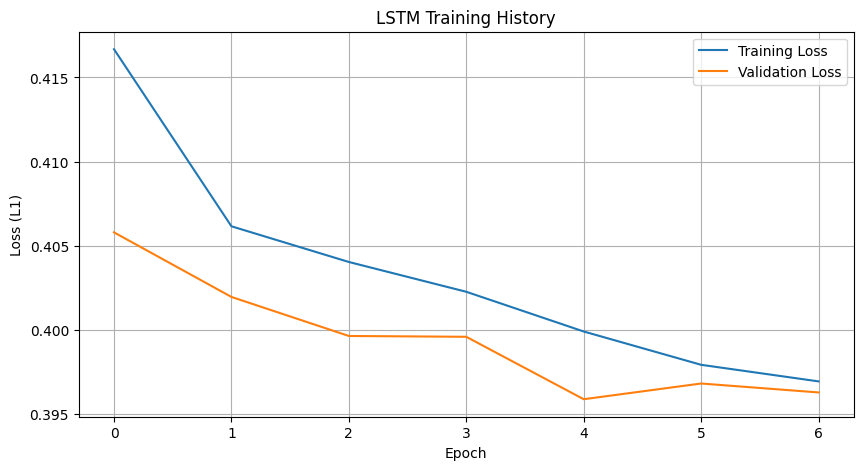


Running LSTM Imputation for Step A...
Starting LSTM Autoencoder Imputation...
Using device for inference: cuda:0


Imputing test series:   1%|          | 18/3127 [02:00<5:46:46,  6.69s/it]


KeyboardInterrupt: 

In [ ]:
print("\nTraining LSTM Autoencoder...")
# Use a smaller subset/fewer epochs for demonstration
lstm_model, lstm_scaler, lstm_history = train_lstm_autoencoder(
    train_data_processed, 
    window_size=24, # Smaller window
    hidden_dim=256,
    num_layers=4,
    epochs=10, # Fewer epochs
    batch_size=1024, # This will be multiplied by num_gpus inside the function
    patience=2
)

print("LSTM Training History:", lstm_history)

#--- Example Plotting ---
plt.figure(figsize=(10, 5))
plt.plot(lstm_history['train_loss'], label='Training Loss')
plt.plot(lstm_history['val_loss'], label='Validation Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (L1)')
plt.legend()
plt.grid(True)
plt.show()
#--- End Example Plotting ---


print("\nRunning LSTM Imputation for Step A...")
test_a_subset = test_data_step_a.copy() # Small test subset
imputed_a_lstm = lstm_autoencoder_imputation(test_a_subset, lstm_model, lstm_scaler, window_size=24)
print(f"Imputed Step A shape: {imputed_a_lstm.shape}, Contains NaNs: {np.isnan(imputed_a_lstm).any()}")

print("\nRunning LSTM Imputation for Step B...")
test_b_subset = test_data_step_b.copy() # Small test subset
imputed_b_lstm = lstm_autoencoder_imputation(test_b_subset, lstm_model, lstm_scaler, window_size=24)
print(f"Imputed Step B shape: {imputed_b_lstm.shape}, Contains NaNs: {np.isnan(imputed_b_lstm).any()}")

pd.DataFrame(imputed_a_lstm).to_csv("testa_m3.csv")
pd.DataFrame(imputed_b_lstm).to_csv("testb_m3.csv")


In [9]:
print("\nRunning LSTM Imputation for Step B...")
test_b_subset = test_data_step_b.copy()  # Small test subset
# Using the new optimized function with batch_size parameter
imputed_b_lstm = lstm_autoencoder_imputation(test_b_subset, lstm_model, lstm_scaler, window_size=24, batch_size=275)
print(f"Imputed Step B shape: {imputed_b_lstm.shape}, Contains NaNs: {np.isnan(imputed_b_lstm).any()}")


Running LSTM Imputation for Step B...
Starting LSTM Autoencoder Imputation with Multi-GPU support...
Using DataParallel across 4 GPUs for inference
Using effective batch size: 1100 (275 per GPU)
Found 6373738 NaN positions to impute
Imputing using past context...


  1%|          | 50081/6373738 [00:00<00:25, 251676.00it/s]<ipython-input-8-a6ee94e71b51>:369: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:278.)
  context_tensor = torch.tensor(batch_contexts, dtype=torch.float32).reshape(-1, window_size, 1).to(inference_device)
100%|██████████| 6373738/6373738 [00:25<00:00, 247148.37it/s]


Imputing using future context...


100%|██████████| 6373738/6373738 [00:27<00:00, 231734.29it/s]


Final fallback imputation for remaining NaNs...


100%|██████████| 1098/1098 [20:19<00:00,  1.11s/it]


Inverse scaling imputed values...
Multi-GPU LSTM Autoencoder Imputation finished.
Imputed Step B shape: (1098, 12864), Contains NaNs: False


In [11]:
pd.DataFrame(imputed_b_lstm).to_csv("testb_m3.csv")


In [13]:
print("\nRunning LSTM Imputation for Step A...")
test_a_subset = test_data_step_a.copy() # Small test subset
imputed_a_lstm = lstm_autoencoder_imputation(test_a_subset, lstm_model, lstm_scaler, window_size=24, batch_size=275)
print(f"Imputed Step A shape: {imputed_a_lstm.shape}, Contains NaNs: {np.isnan(imputed_a_lstm).any()}")


Running LSTM Imputation for Step A...
Starting LSTM Autoencoder Imputation with Multi-GPU support...
Using DataParallel across 4 GPUs for inference
Using effective batch size: 1100 (275 per GPU)
Found 12058326 NaN positions to impute
Imputing using past context...


100%|██████████| 12058326/12058326 [00:51<00:00, 234548.30it/s]


Imputing using future context...


100%|██████████| 12058326/12058326 [00:54<00:00, 223160.86it/s]


Final fallback imputation for remaining NaNs...


100%|██████████| 3127/3127 [48:14<00:00,  1.08it/s]


Inverse scaling imputed values...
Multi-GPU LSTM Autoencoder Imputation finished.
Imputed Step A shape: (3127, 12864), Contains NaNs: False


In [15]:
pd.DataFrame(imputed_a_lstm).to_csv("testa_m3.csv")


# Partial Convolution Inpainting

In [4]:

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms.functional import resize # Use functional resize

import pandas as pd
import numpy as np
import os
import math
import time
import random
from collections import OrderedDict # Import OrderedDict
from sklearn.preprocessing import RobustScaler # Import RobustScaler

# --- Configuration ---
# Data parameters
TRAIN_CSV = '/kaggle/input/dataset-stepb/train.csv' # Path to your training data
TEST_CSV = '/kaggle/input/dataset-stepb/test.csv'   # Path to your test data
N_HOUSES_TRAIN = 3127
N_HOUSES_TEST = 1098
N_TIMEPOINTS = 12864 # Original number of timepoints
TIMEPOINTS_PER_WEEK = 336 # 48 readings/day * 7 days/week

# Padding Calculation
N_WEEKS_PADDED = math.ceil(N_TIMEPOINTS / TIMEPOINTS_PER_WEEK)
PADDED_LEN = N_WEEKS_PADDED * TIMEPOINTS_PER_WEEK
PAD_SIZE = PADDED_LEN - N_TIMEPOINTS
print(f"Original Length: {N_TIMEPOINTS}")
print(f"Timepoints per Week: {TIMEPOINTS_PER_WEEK}")
print(f"Calculated Padded Weeks: {N_WEEKS_PADDED}")
print(f"Calculated Padded Length: {PADDED_LEN}")
print(f"Padding Size: {PAD_SIZE}")

# Model parameters
IMG_SIZE = 256
INPUT_CHANNELS = 1
OUTPUT_CHANNELS = 1

# Training parameters
BATCH_SIZE = 64
N_EPOCHS = 10
LEARNING_RATE = 0.01
MASK_RATE_MIN = 0.30
MASK_RATE_MAX = 0.50
MASK_MODE = 'random_continuous'
NUM_WORKERS = 20
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_GPUS = torch.cuda.device_count() if torch.cuda.is_available() else 0

# Prediction Batch Size
PREDICTION_BATCH_SIZE = BATCH_SIZE // 2
PREDICTION_BATCH_SIZE = max(1, PREDICTION_BATCH_SIZE)

# Output parameters
MODEL_SAVE_PATH = 'pconv_imputation_model_robust_padded.pth' # Updated model name
PREDICTIONS_SAVE_PATH = 'imputed_test_data_robust_full_length.csv' # Updated output name

print(f"--- Configuration ---")
print(f"Device: {DEVICE}")
print(f"Number of GPUs: {N_GPUS}")
print(f"Training Batch Size: {BATCH_SIZE}")
print(f"Prediction Batch Size: {PREDICTION_BATCH_SIZE}")
print(f"Image Size for Model: {IMG_SIZE}x{IMG_SIZE}")
print(f"Original Time Series Length: {N_TIMEPOINTS}")
print(f"Padded Time Series Length for Model: {PADDED_LEN}")
print(f"Using RobustScaler for normalization.")
print(f"---------------------\n")

# --- Data Loading and Preprocessing ---

class EnergyTimeSeriesDataset(Dataset):
    """Dataset for energy time series with padding and RobustScaler."""
    def __init__(self, csv_path, n_rows, n_cols_original, n_cols_padded, pad_size, timepoints_per_week, n_weeks_padded, img_size, is_train=True, normalize=True):
        print(f"Loading data from {csv_path}...")
        self.data = pd.read_csv(csv_path, nrows=n_rows, low_memory=False).values
        print(f"Data shape loaded: {self.data.shape}")

        if self.data.shape[1] < n_cols_original:
            raise ValueError(f"Data has {self.data.shape[1]} columns, but {n_cols_original} are expected.")

        self.data = self.data[:, :n_cols_original].astype(np.float32)
        print(f"Data shape after selecting original columns: {self.data.shape}")

        self.n_rows = n_rows
        self.n_cols_original = n_cols_original
        self.n_cols_padded = n_cols_padded
        self.pad_size = pad_size
        self.timepoints_per_week = timepoints_per_week
        self.n_weeks_padded = n_weeks_padded
        self.img_size = img_size
        self.is_train = is_train
        self.normalize = normalize # Controls whether RobustScaler is used

        # --- RobustScaler Implementation ---
        self.scaler_centers = [] # Store median (center) for each series
        self.scaler_scales = []  # Store IQR (scale) for each series
        data_normalized_list = []

        print("Applying RobustScaler row by row...")
        for i in range(self.n_rows):
            series = self.data[i].reshape(-1, 1) # Reshape for scaler
            # Handle NaNs before fitting/transforming. Using 0 might affect median/IQR.
            # Consider fitting only on non-NaNs if performance is critical, but nan_to_num is simpler.
            series_clean = np.nan_to_num(series, nan=0.0) # Replace NaN with 0 for scaling

            if self.normalize:
                scaler = RobustScaler()
                scaled_series = scaler.fit_transform(series_clean)
                # Store scaler parameters instead of the scaler object
                self.scaler_centers.append(scaler.center_[0]) # Store median
                self.scaler_scales.append(scaler.scale_[0])   # Store IQR / 1.35
                data_normalized_list.append(scaled_series.flatten())
            else:
                # If not normalizing, just use the cleaned data
                self.scaler_centers.append(0) # Store dummy values
                self.scaler_scales.append(1)
                data_normalized_list.append(series_clean.flatten())

            if (i + 1) % 500 == 0:
                 print(f"  Scaled {i+1}/{self.n_rows} series...")

        self.data_normalized = np.array(data_normalized_list, dtype=np.float32)
        print("RobustScaler application complete.")
        # ------------------------------------

        # Pad the NORMALIZED data
        print(f"Padding normalized data to length {self.n_cols_padded}...")
        pad_width = ((0, 0), (0, self.pad_size))
        self.data_padded_normalized = np.pad(self.data_normalized, pad_width, mode='constant', constant_values=0)
        print(f"Data shape after padding: {self.data_padded_normalized.shape}")

        # Pre-reshape and resize PADDED data
        print("Pre-reshaping and resizing padded data...")
        self.reshaped_data = []
        target_shape = (self.timepoints_per_week, self.n_weeks_padded)
        for i in range(self.n_rows):
            series = torch.tensor(self.data_padded_normalized[i], dtype=torch.float32)
            reshaped_series = series.view(target_shape)
            resized_series = resize(reshaped_series.unsqueeze(0), [self.img_size, self.img_size], antialias=True)
            self.reshaped_data.append(resized_series.squeeze(0))
            if (i + 1) % 500 == 0:
                 print(f"  Reshaped/Resized {i+1}/{self.n_rows} series...")
        print("Pre-reshaping and resizing complete.")


    def __len__(self):
        return self.n_rows

    def __getitem__(self, idx):
        data_img_padded = self.reshaped_data[idx]

        if self.is_train:
            mask = self.generate_mask(data_img_padded.shape)
            masked_data_img = data_img_padded * (1. - mask)
            model_input = torch.stack([masked_data_img, mask], dim=0)
            target = data_img_padded.unsqueeze(0)
            return model_input, target
        else:
            # Create Mask from NaNs for Testing (Based on ORIGINAL length)
            original_series = torch.tensor(pd.read_csv(TEST_CSV, skiprows=idx, nrows=1).values[0, :self.n_cols_original], dtype=torch.float32)
            nan_mask_1d_original = torch.isnan(original_series)
            nan_mask_1d_padded = F.pad(nan_mask_1d_original.float(), (0, self.pad_size), mode='constant', value=0)
            nan_mask_2d_padded = nan_mask_1d_padded.view(self.timepoints_per_week, self.n_weeks_padded)
            mask = resize(nan_mask_2d_padded.unsqueeze(0), [self.img_size, self.img_size], antialias=False).squeeze(0)
            mask = (mask > 0.5).float()

            # Prepare model input using the PADDED normalized data
            masked_data_img = data_img_padded * (1. - mask)
            model_input = torch.stack([masked_data_img, mask], dim=0)

            original_normalized_img_padded = data_img_padded.unsqueeze(0)
            return model_input, original_normalized_img_padded, mask.unsqueeze(0)

    def generate_mask(self, img_shape):
        """Generates a random mask for training."""
        mask = torch.zeros(img_shape, dtype=torch.float32)
        h, w = img_shape
        mask_rate = random.uniform(MASK_RATE_MIN, MASK_RATE_MAX)
        current_mask_mode = random.choice(['random_day', 'continuous_block', 'random_continuous_mix'])

        if current_mask_mode == 'random_day':
            num_masked_cols = int(w * mask_rate)
            if num_masked_cols > 0 and w > 0:
                masked_cols = random.sample(range(w), num_masked_cols)
                mask[:, masked_cols] = 1.0
        elif current_mask_mode == 'continuous_block':
            block_h = int(h * math.sqrt(mask_rate) * random.uniform(0.8, 1.2))
            block_w = int(w * math.sqrt(mask_rate) * random.uniform(0.8, 1.2))
            block_h = min(max(1, block_h), h); block_w = min(max(1, block_w), w)
            if h > block_h and w > block_w:
                start_h = random.randint(0, h - block_h); start_w = random.randint(0, w - block_w)
                mask[start_h : start_h + block_h, start_w : start_w + block_w] = 1.0
            elif h > 0 and w > 0: mask[:,:] = 1.0
        elif current_mask_mode == 'random_continuous_mix':
             if random.random() < 0.5:
                 num_masked_cols = int(w * mask_rate)
                 if num_masked_cols > 0 and w > 0:
                     masked_cols = random.sample(range(w), num_masked_cols)
                     mask[:, masked_cols] = 1.0
             else:
                 block_h = int(h * math.sqrt(mask_rate) * random.uniform(0.8, 1.2))
                 block_w = int(w * math.sqrt(mask_rate) * random.uniform(0.8, 1.2))
                 block_h = min(max(1, block_h), h); block_w = min(max(1, block_w), w)
                 if h > block_h and w > block_w:
                     start_h = random.randint(0, h - block_h); start_w = random.randint(0, w - block_w)
                     mask[start_h : start_h + block_h, start_w : start_w + block_w] = 1.0
                 elif h > 0 and w > 0: mask[:,:] = 1.0
        return mask

    # --- >> Renamed denormalize to inverse_transform << ---
    def inverse_transform(self, data_scaled, idx):
        """Applies inverse RobustScaler transform using stored parameters."""
        if not self.normalize:
            # If normalization was skipped, data_scaled is already in original scale (except for handled NaNs)
             if isinstance(data_scaled, torch.Tensor):
                 data_scaled = data_scaled.cpu().numpy()
             return data_scaled # Return as is

        center = self.scaler_centers[idx]
        scale = self.scaler_scales[idx]

        if isinstance(data_scaled, torch.Tensor):
            data_scaled = data_scaled.cpu().numpy()

        # Handle potential division by zero if scale is near zero
        if scale < 1e-8:
             print(f"Warning: Near-zero scale ({scale}) encountered for index {idx}. Inverse transform might be inaccurate. Returning center value.")
             # Return the median value (center) for all points as a fallback
             return np.full(data_scaled.shape, center, dtype=data_scaled.dtype)

        # Apply inverse transform: X_original = (X_scaled * scale) + center
        original_data = (data_scaled * scale) + center
        return original_data
    # -------------------------------------------------------


# --- Partial Convolution Layer ---
# (No changes needed)
class PartialConv2d(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super(PartialConv2d, self).__init__(*args, **kwargs)
        self.register_buffer('weight_maskUpdater', torch.ones(1, 1, self.kernel_size[0], self.kernel_size[1]))
        self.slide_winsize = float(self.in_channels * self.kernel_size[0] * self.kernel_size[1])
    def forward(self, input_tensor, mask_in=None):
        assert mask_in is not None; assert input_tensor.shape[2:] == mask_in.shape[2:]; assert mask_in.shape[1] == 1
        mask = 1. - mask_in
        with torch.no_grad():
            update_mask = F.conv2d(mask, self.weight_maskUpdater.to(mask.device), bias=None, stride=self.stride, padding=self.padding, dilation=self.dilation, groups=1)
            mask_ratio = self.slide_winsize / (update_mask + 1e-8); update_mask = torch.clamp(update_mask, 0, 1); mask_ratio = mask_ratio * update_mask
        masked_input = input_tensor * mask.expand_as(input_tensor)
        raw_out = super(PartialConv2d, self).forward(masked_input)
        if self.bias is not None: output = raw_out * mask_ratio
        else: output = raw_out * mask_ratio
        new_mask = 1. - update_mask
        return output, new_mask

# --- PConv U-Net Model ---
# (No changes needed)
class PConvUNet(nn.Module):
    def __init__(self, input_channels=1, output_channels=1, n_filters=64):
        super().__init__()
        self.enc1_conv=PartialConv2d(input_channels, n_filters, 7, 2, 3); self.enc1_bn=nn.BatchNorm2d(n_filters); self.enc1_act=nn.ReLU(True)
        self.enc2_conv=PartialConv2d(n_filters, n_filters*2, 5, 2, 2); self.enc2_bn=nn.BatchNorm2d(n_filters*2); self.enc2_act=nn.ReLU(True)
        self.enc3_conv=PartialConv2d(n_filters*2, n_filters*4, 5, 2, 2); self.enc3_bn=nn.BatchNorm2d(n_filters*4); self.enc3_act=nn.ReLU(True)
        self.enc4_conv=PartialConv2d(n_filters*4, n_filters*8, 3, 2, 1); self.enc4_bn=nn.BatchNorm2d(n_filters*8); self.enc4_act=nn.ReLU(True)
        self.enc5_conv=PartialConv2d(n_filters*8, n_filters*8, 3, 2, 1); self.enc5_bn=nn.BatchNorm2d(n_filters*8); self.enc5_act=nn.ReLU(True)
        self.enc6_conv=PartialConv2d(n_filters*8, n_filters*8, 3, 2, 1); self.enc6_bn=nn.BatchNorm2d(n_filters*8); self.enc6_act=nn.ReLU(True)
        self.dec6_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec6_conv=PartialConv2d(n_filters*8+n_filters*8, n_filters*8, 3, 1, 1); self.dec6_bn=nn.BatchNorm2d(n_filters*8); self.dec6_act=nn.LeakyReLU(0.2, True)
        self.dec5_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec5_conv=PartialConv2d(n_filters*8+n_filters*8, n_filters*8, 3, 1, 1); self.dec5_bn=nn.BatchNorm2d(n_filters*8); self.dec5_act=nn.LeakyReLU(0.2, True)
        self.dec4_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec4_conv=PartialConv2d(n_filters*4+n_filters*8, n_filters*4, 3, 1, 1); self.dec4_bn=nn.BatchNorm2d(n_filters*4); self.dec4_act=nn.LeakyReLU(0.2, True)
        self.dec3_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec3_conv=PartialConv2d(n_filters*2+n_filters*4, n_filters*2, 3, 1, 1); self.dec3_bn=nn.BatchNorm2d(n_filters*2); self.dec3_act=nn.LeakyReLU(0.2, True)
        self.dec2_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec2_conv=PartialConv2d(n_filters+n_filters*2, n_filters, 3, 1, 1); self.dec2_bn=nn.BatchNorm2d(n_filters); self.dec2_act=nn.LeakyReLU(0.2, True)
        self.dec1_upsample=nn.Upsample(scale_factor=2, mode='nearest'); self.dec1_conv=PartialConv2d(input_channels+n_filters, n_filters, 3, 1, 1); self.dec1_bn=nn.BatchNorm2d(n_filters); self.dec1_act=nn.LeakyReLU(0.2, True)
        self.final_conv=nn.Conv2d(n_filters, output_channels, 1)
    def forward(self, i, m):
        x=i;e1,m1=self.enc1_conv(x, m);e1=self.enc1_act(self.enc1_bn(e1));e2,m2=self.enc2_conv(e1, m1);e2=self.enc2_act(self.enc2_bn(e2));e3,m3=self.enc3_conv(e2, m2);e3=self.enc3_act(self.enc3_bn(e3));e4,m4=self.enc4_conv(e3, m3);e4=self.enc4_act(self.enc4_bn(e4));e5,m5=self.enc5_conv(e4, m4);e5=self.enc5_act(self.enc5_bn(e5));e6,m6=self.enc6_conv(e5, m5);e6=self.enc6_act(self.enc6_bn(e6))
        d6u=self.dec6_upsample(e6);m6u=self.dec6_upsample(m6);d6=torch.cat([d6u,e5],1);d6,md6=self.dec6_conv(d6, m6u);d6=self.dec6_act(self.dec6_bn(d6))
        d5u=self.dec5_upsample(d6);m5u=self.dec5_upsample(md6);d5=torch.cat([d5u,e4],1);d5,md5=self.dec5_conv(d5, m5u);d5=self.dec5_act(self.dec5_bn(d5))
        d4u=self.dec4_upsample(d5);m4u=self.dec4_upsample(md5);d4=torch.cat([d4u,e3],1);d4,md4=self.dec4_conv(d4, m4u);d4=self.dec4_act(self.dec4_bn(d4))
        d3u=self.dec3_upsample(d4);m3u=self.dec3_upsample(md4);d3=torch.cat([d3u,e2],1);d3,md3=self.dec3_conv(d3, m3u);d3=self.dec3_act(self.dec3_bn(d3))
        d2u=self.dec2_upsample(d3);m2u=self.dec2_upsample(md3);d2=torch.cat([d2u,e1],1);d2,md2=self.dec2_conv(d2, m2u);d2=self.dec2_act(self.dec2_bn(d2))
        d1u=self.dec1_upsample(d2);m1u=self.dec1_upsample(md2);d1=torch.cat([d1u,x],1);d1,md1=self.dec1_conv(d1, m1u);d1=self.dec1_act(self.dec1_bn(d1))
        o=self.final_conv(d1);o=torch.sigmoid(o);return o

# --- Training Function ---
# (No changes needed)
def train_model(model, train_loader, criterion, optimizer, n_epochs, device):
    print("\n--- Starting Training ---"); model.train()
    if N_GPUS > 1: print(f"Using {N_GPUS} GPUs."); model = nn.DataParallel(model)
    model.to(device)
    for epoch in range(n_epochs):
        t_start=time.time(); loss_run=0.0; batches=0
        for i, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)
            masked_imgs=inputs[:, 0:1]; masks=inputs[:, 1:2]
            optimizer.zero_grad(); outputs=model(masked_imgs, masks)
            loss=criterion(outputs, targets, masks); loss.backward(); optimizer.step()
            loss_run+=loss.item(); batches+=1
            if (i+1)%20==0: print(f'E[{epoch+1}/{n_epochs}], B[{i+1}/{len(train_loader)}], L:{loss.item():.4f}')
        print(f'--- E{epoch+1} Summary --- Loss: {loss_run/batches:.4f}, Time: {time.time()-t_start:.2f}s\n')
    print("--- Training Finished ---")
    model_to_save=model.module if isinstance(model, nn.DataParallel) else model
    torch.save(model_to_save.state_dict(), MODEL_SAVE_PATH); print(f"Model saved: {MODEL_SAVE_PATH}")

# --- Prediction Function ---

def predict_and_save(model, test_loader, device, original_shape_padded, target_len_original):
    print("\n--- Starting Prediction ---"); model.eval(); model.to(device)
    all_imputed = []
    print(f"Loading original test data: {TEST_CSV}"); original_test_data = pd.read_csv(TEST_CSV, nrows=N_HOUSES_TEST).values
    if original_test_data.shape[1]<target_len_original: raise ValueError("Test data shorter than expected")
    original_test_data = original_test_data[:, :target_len_original].astype(np.float32); print("Original test data loaded.")
    with torch.no_grad():
        bs=test_loader.batch_size; print(f"Prediction batch size: {bs}")
        for i, (inputs, orig_norm_padded, masks_padded) in enumerate(test_loader):
            inputs, orig_norm_padded, masks_padded = inputs.to(device), orig_norm_padded.to(device), masks_padded.to(device)
            masked_imgs = inputs[:, 0:1]; inference_masks = masks_padded
            predicted_imgs = model(masked_imgs, inference_masks)
            imputed_norm_padded = orig_norm_padded*(1.-inference_masks) + predicted_imgs*inference_masks
            imputed_norm_padded_cpu = imputed_norm_padded.cpu()
            start_idx=i*bs; end_idx=min(start_idx+bs, len(test_loader.dataset)); batch_indices=range(start_idx, end_idx)
            for j, idx in enumerate(batch_indices):
                img_padded = imputed_norm_padded_cpu[j].squeeze(0)
                resized_padded = resize(img_padded.unsqueeze(0), [original_shape_padded[0], original_shape_padded[1]], antialias=True).squeeze(0)
                series_norm_padded = resized_padded.view(-1)
                # --- >> TRUNCATE << ---
                series_norm_original = series_norm_padded[:target_len_original]
                # --- >> INVERSE TRANSFORM << ---
                series_denorm_original = test_loader.dataset.inverse_transform(series_norm_original, idx)
                # -------------------------
                original_row = original_test_data[idx].copy()
                nan_indices = np.isnan(original_row)
                if len(series_denorm_original) != len(nan_indices): print(f"W: Len mismatch idx {idx}. Skipping NaN fill.")
                else: original_row[nan_indices] = series_denorm_original[nan_indices]
                original_row = np.nan_to_num(original_row, nan=0.0)
                all_imputed.append(original_row)
                if (idx+1)%100==0: print(f"  Processed {idx+1}/{len(test_loader.dataset)}")
    print("--- Prediction Finished ---")
    print(f"Saving {len(all_imputed)} rows: {PREDICTIONS_SAVE_PATH}"); imputed_df = pd.DataFrame(all_imputed)
    if imputed_df.shape[1] != target_len_original: print(f"FATAL: Output cols {imputed_df.shape[1]} != {target_len_original}")
    else: imputed_df.to_csv(PREDICTIONS_SAVE_PATH, index=False); print("Predictions saved.")


# --- Main Execution ---

if __name__ == '__main__':
    print("Preparing Training Dataset...")
    train_dataset = EnergyTimeSeriesDataset(
        csv_path=TRAIN_CSV, n_rows=N_HOUSES_TRAIN, n_cols_original=N_TIMEPOINTS,
        n_cols_padded=PADDED_LEN, pad_size=PAD_SIZE, timepoints_per_week=TIMEPOINTS_PER_WEEK,
        n_weeks_padded=N_WEEKS_PADDED, img_size=IMG_SIZE, is_train=True, normalize=True)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE * max(1, N_GPUS), shuffle=True,
                              num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
    print("Training Dataset Prepared.")

    print("Initializing Model..."); pconv_model = PConvUNet(INPUT_CHANNELS, OUTPUT_CHANNELS); print("Model Initialized.")
    def pconv_mae_loss(y_pred, y_true, mask): loss=torch.sum(torch.abs(y_pred*mask - y_true*mask)); mask_sum=torch.sum(mask)+1e-8; return loss/mask_sum
    criterion = pconv_mae_loss; optimizer = optim.Adam(pconv_model.parameters(), lr=LEARNING_RATE)

    print("Starting Training...")
    train_model(pconv_model, train_loader, criterion, optimizer, N_EPOCHS, DEVICE)

    print("Preparing Test Dataset...")
    test_dataset = EnergyTimeSeriesDataset(
        csv_path=TEST_CSV, n_rows=N_HOUSES_TEST, n_cols_original=N_TIMEPOINTS,
        n_cols_padded=PADDED_LEN, pad_size=PAD_SIZE, timepoints_per_week=TIMEPOINTS_PER_WEEK,
        n_weeks_padded=N_WEEKS_PADDED, img_size=IMG_SIZE, is_train=False, normalize=True)
    test_loader = DataLoader(test_dataset, batch_size=PREDICTION_BATCH_SIZE * max(1, N_GPUS), shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
    print("Test Dataset Prepared.")

    print(f"Loading model: {MODEL_SAVE_PATH}...")
    prediction_model = PConvUNet(INPUT_CHANNELS, OUTPUT_CHANNELS)
    state_dict = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
    if any(k.startswith('module.') for k in state_dict):
        print("Adjusting state_dict: Removing 'module.' prefix.")
        new_state_dict=OrderedDict(); [(new_state_dict.update({k[7:]:v})) for k,v in state_dict.items()]; state_dict=new_state_dict
    try: prediction_model.load_state_dict(state_dict); print("State dict loaded.")
    except RuntimeError as e: print(f"Error loading state_dict: {e}"); raise e
    print("Model ready for prediction.")

    predict_and_save(model=prediction_model, test_loader=test_loader, device=DEVICE,
                     original_shape_padded=(TIMEPOINTS_PER_WEEK, N_WEEKS_PADDED),
                     target_len_original=N_TIMEPOINTS)

    print("\n--- Pipeline Finished ---")


Original Length: 12864
Timepoints per Week: 336
Calculated Padded Weeks: 39
Calculated Padded Length: 13104
Padding Size: 240
--- Configuration ---
Device: cuda
Number of GPUs: 4
Training Batch Size: 64
Prediction Batch Size: 32
Image Size for Model: 256x256
Original Time Series Length: 12864
Padded Time Series Length for Model: 13104
Using RobustScaler for normalization.
---------------------

Preparing Training Dataset...
Loading data from /kaggle/input/dataset-stepb/train.csv...
Data shape loaded: (3127, 12864)
Data shape after selecting original columns: (3127, 12864)
Applying RobustScaler row by row...
  Scaled 500/3127 series...
  Scaled 1000/3127 series...
  Scaled 1500/3127 series...
  Scaled 2000/3127 series...
  Scaled 2500/3127 series...
  Scaled 3000/3127 series...
RobustScaler application complete.
Padding normalized data to length 13104...
Data shape after padding: (3127, 13104)
Pre-reshaping and resizing padded data...
  Reshaped/Resized 500/3127 series...
  Reshaped/Res

<ipython-input-4-9bcbc1f5b847>:376: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)


State dict loaded.
Model ready for prediction.

--- Starting Prediction ---
Loading original test data: /kaggle/input/dataset-stepb/test.csv
Original test data loaded.
Prediction batch size: 128
  Processed 100/1098
  Processed 200/1098
  Processed 300/1098
  Processed 400/1098
  Processed 500/1098
  Processed 600/1098
  Processed 700/1098
  Processed 800/1098
  Processed 900/1098
  Processed 1000/1098
--- Prediction Finished ---
Saving 1098 rows: imputed_test_data_robust_full_length.csv
Predictions saved.

--- Pipeline Finished ---


In [7]:
TEST_CSV = "/kaggle/input/master-1-data-challenge-ts-imputation-step-1/test.csv"
N_HOUSES_TEST = 3127
print("Preparing Test Dataset...")
test_dataset = EnergyTimeSeriesDataset(
    csv_path=TEST_CSV, n_rows=N_HOUSES_TEST, n_cols_original=N_TIMEPOINTS,
    n_cols_padded=PADDED_LEN, pad_size=PAD_SIZE, timepoints_per_week=TIMEPOINTS_PER_WEEK,
    n_weeks_padded=N_WEEKS_PADDED, img_size=IMG_SIZE, is_train=False, normalize=True)
test_loader = DataLoader(test_dataset, batch_size=PREDICTION_BATCH_SIZE * max(1, N_GPUS), shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True, drop_last=False)
print("Test Dataset Prepared.")
print(f"Loading model: {MODEL_SAVE_PATH}...")
prediction_model = PConvUNet(INPUT_CHANNELS, OUTPUT_CHANNELS)
state_dict = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)
if any(k.startswith('module.') for k in state_dict):
    print("Adjusting state_dict: Removing 'module.' prefix.")
    new_state_dict=OrderedDict(); [(new_state_dict.update({k[7:]:v})) for k,v in state_dict.items()]; state_dict=new_state_dict
try: prediction_model.load_state_dict(state_dict); print("State dict loaded.")
except RuntimeError as e: print(f"Error loading state_dict: {e}"); raise e
print("Model ready for prediction.")
predict_and_save(model=prediction_model, test_loader=test_loader, device=DEVICE,
                 original_shape_padded=(TIMEPOINTS_PER_WEEK, N_WEEKS_PADDED),
                 target_len_original=N_TIMEPOINTS)
print("\n--- Pipeline Finished ---")

Preparing Test Dataset...
Loading data from /kaggle/input/master-1-data-challenge-ts-imputation-step-1/test.csv...
Data shape loaded: (3127, 12864)
Data shape after selecting original columns: (3127, 12864)
Applying RobustScaler row by row...
  Scaled 500/3127 series...
  Scaled 1000/3127 series...
  Scaled 1500/3127 series...
  Scaled 2000/3127 series...
  Scaled 2500/3127 series...
  Scaled 3000/3127 series...
RobustScaler application complete.
Padding normalized data to length 13104...
Data shape after padding: (3127, 13104)
Pre-reshaping and resizing padded data...
  Reshaped/Resized 500/3127 series...
  Reshaped/Resized 1000/3127 series...
  Reshaped/Resized 1500/3127 series...
  Reshaped/Resized 2000/3127 series...
  Reshaped/Resized 2500/3127 series...
  Reshaped/Resized 3000/3127 series...
Pre-reshaping and resizing complete.
Test Dataset Prepared.
Loading model: pconv_imputation_model_robust_padded.pth...


<ipython-input-7-15b0636a9eff>:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(MODEL_SAVE_PATH, map_location=DEVICE)


State dict loaded.
Model ready for prediction.

--- Starting Prediction ---
Loading original test data: /kaggle/input/master-1-data-challenge-ts-imputation-step-1/test.csv
Original test data loaded.
Prediction batch size: 128
  Processed 100/3127
  Processed 200/3127
  Processed 300/3127
  Processed 400/3127
  Processed 500/3127
  Processed 600/3127
  Processed 700/3127
  Processed 800/3127
  Processed 900/3127
  Processed 1000/3127
  Processed 1100/3127
  Processed 1200/3127
  Processed 1300/3127
  Processed 1400/3127
  Processed 1500/3127
  Processed 1600/3127
  Processed 1700/3127
  Processed 1800/3127
  Processed 1900/3127
  Processed 2000/3127
  Processed 2100/3127
  Processed 2200/3127
  Processed 2300/3127
  Processed 2400/3127
  Processed 2500/3127
  Processed 2600/3127
  Processed 2700/3127
  Processed 2800/3127
  Processed 2900/3127
  Processed 3000/3127
  Processed 3100/3127
--- Prediction Finished ---
Saving 3127 rows: imputed_test_data_robust_full_length.csv
Predictions sa

In [8]:
pred = pd.read_csv("/kaggle/working/imputed_test_data_robust_full_length.csv")
pred

,0,1,2,3,4,5,6,7,8,9,...,12854,12855,12856,12857,12858,12859,12860,12861,12862,12863
0,0.243000,0.216000,1.045000,0.621000,0.963000,0.405000,0.437000,0.668000,0.274000,0.285,...,0.730000,0.735000,1.075000,1.113000,2.354000,0.880000,0.794000,0.772000,0.771000,0.885000
1,0.082782,0.088826,0.076771,0.073495,0.110499,0.094000,0.044000,0.071000,0.071000,0.045,...,0.100095,0.044505,0.036723,0.041599,0.035564,0.045856,0.077250,0.081751,0.055354,0.058033
2,0.102000,0.058000,0.050000,0.065000,0.063000,0.105000,0.069000,0.161971,0.091910,0.062,...,0.057417,0.047774,0.040643,0.037927,0.034947,0.040808,0.048457,0.038503,0.039277,0.043713
3,0.347000,0.315000,0.268000,0.288000,0.314000,0.325000,0.274000,0.261000,0.273000,0.245,...,0.214160,0.195262,0.187068,0.187595,0.180478,0.178133,0.166716,0.164090,0.166414,0.186738
4,0.320000,0.274000,0.284000,0.568000,1.312000,1.687000,1.326000,0.362000,0.306000,0.322,...,0.192000,0.225000,0.208000,0.300000,0.331000,0.318000,0.119000,0.177000,0.221000,0.140000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3122,0.020057,0.021762,0.027305,0.027583,0.028697,0.025598,0.024576,0.028284,0.037113,0.084,...,0.225000,0.245000,0.342000,0.227000,0.225000,0.223000,0.275000,0.304000,0.220000,0.219000
3123,0.136000,0.207000,0.127000,0.167000,0.148000,0.063000,0.137000,0.110000,0.151000,0.098,...,0.703000,0.612000,0.706000,0.487000,0.403000,0.354000,0.361000,0.325000,0.385000,0.301000
3124,0.180000,0.125000,0.049000,0.049000,0.048000,0.049000,0.046000,0.033000,0.062000,0.093,...,0.109366,0.115250,0.130498,0.432000,0.407000,0.406000,0.408000,0.408000,0.399000,0.327000
3125,0.117000,0.101000,0.168000,0.102000,0.103000,0.168000,0.105000,0.102000,0.139000,0.139,...,0.264000,0.287000,0.270000,0.369000,0.345000,0.102451,0.084825,0.088735,0.089423,0.090850


# Transformer-Based Imputation

In [16]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torch.multiprocessing as mp
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import math
import random
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import autocast, GradScaler

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configuration parameters
class Config:
    # Data parameters
    TRAIN_FILE = '/kaggle/input/dataset-stepb/train.csv'
    TEST_FILE = '/kaggle/input/master-1-data-challenge-ts-imputation-step-1/test.csv'
    OUTPUT_FILE = 'predictions.csv'
    MODEL_SAVE_PATH = 'transformer_imputation_model.pth'
    
    # Model parameters - REDUCED for memory efficiency
    EMBEDDING_DIM = 256  # Reduced from 512
    NUM_ENCODER_LAYERS = 4  # Reduced from 6
    NUM_DECODER_LAYERS = 4  # Reduced from 6
    NUM_HEADS = 8
    DIM_FEEDFORWARD = 512  # Reduced from 2048
    DROPOUT = 0.1
    
    # Training parameters
    BATCH_SIZE = 64  # Reduced from 256
    GRADIENT_ACCUMULATION_STEPS = 4  # Simulate larger batch
    CONTEXT_SIZE = 96  # Context window size
    LEARNING_RATE = 5e-4
    WEIGHT_DECAY = 1e-5
    EPOCHS = 10
    WARMUP_STEPS = 4000
    
    # Infrastructure
    NUM_GPUS = 4
    NUM_WORKERS = 4  # For data loading
    
    # Early stopping
    PATIENCE = 5
    
    # Preprocessing
    OUTLIER_QUANTILE_LOW = 0.25
    OUTLIER_QUANTILE_HIGH = 0.75


def preprocess_data(df, is_training=True, quartile_low=None, quartile_high=None):
    """
    Preprocess the data by handling outliers and applying log normalization.
    
    Args:
        df: Input DataFrame
        is_training: Whether this is training data (to compute quartiles)
        quartile_low: Pre-computed lower quartile (for test data)
        quartile_high: Pre-computed upper quartile (for test data)
    
    Returns:
        Preprocessed DataFrame and quartiles if is_training
    """
    # Create a copy to avoid modifying the original dataframe
    df_processed = df.copy()
    
    if is_training:
        # Calculate quartiles on training data
        quartile_low = df_processed.quantile(Config.OUTLIER_QUANTILE_LOW)
        quartile_high = df_processed.quantile(Config.OUTLIER_QUANTILE_HIGH)
    
    # Replace outliers with the closest quartile
    for col in df_processed.columns:
        df_processed[col] = np.where(df_processed[col] < quartile_low[col], 
                                    quartile_low[col], 
                                    df_processed[col])
        
        df_processed[col] = np.where(df_processed[col] > quartile_high[col], 
                                    quartile_high[col], 
                                    df_processed[col])
    
    # Apply log normalization (adding a small constant to avoid log(0))
    df_processed = np.log1p(df_processed)
    
    if is_training:
        return df_processed, quartile_low, quartile_high
    else:
        return df_processed


def inverse_transform(df, quartile_low, quartile_high):
    """
    Apply inverse transform to get back to original scale.
    """
    # Inverse of log1p is expm1
    df_inverse = np.expm1(df)
    
    # We don't need to reverse the quartile replacement as it's a valid imputation
    
    return df_inverse


class TimeSeriesDataset(Dataset):
    """Dataset for time series imputation with mask generation."""
    
    def __init__(self, data, context_size=96, mask_ratio=0.15):
        """
        Args:
            data: Preprocessed DataFrame of shape (num_houses, num_timestamps)
            context_size: Number of context time steps to consider
            mask_ratio: Ratio of values to mask for training
        """
        self.data = torch.tensor(data.values, dtype=torch.float32)
        self.context_size = context_size
        self.mask_ratio = mask_ratio
        self.num_houses, self.num_timestamps = self.data.shape
    
    def __len__(self):
        return self.num_houses
    
    def __getitem__(self, idx):
        # Get the full time series for a house
        house_data = self.data[idx]
        
        # Create a mask for training (1 = keep original, 0 = mask)
        mask = torch.ones_like(house_data)
        
        # Randomly mask some values
        mask_indices = torch.randperm(self.num_timestamps)[:int(self.num_timestamps * self.mask_ratio)]
        mask[mask_indices] = 0
        
        # Create masked input (replace masked values with 0 for now)
        masked_data = house_data * mask
        
        # Create target (original data)
        target = house_data.clone()
        
        return {
            'input': masked_data,
            'mask': mask,
            'target': target
        }


class PositionalEncoding(nn.Module):
    """Positional encoding for the transformer model."""
    
    def __init__(self, d_model, max_len=12864):
        super(PositionalEncoding, self).__init__()
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))
        
    def forward(self, x):
        # x shape: [batch_size, seq_len, embedding_dim]
        return x + self.pe[:, :x.size(1), :]


class TransformerImputer(nn.Module):
    """Transformer model for time series imputation with bi-directional capability."""
    
    def __init__(self, d_model=512, nhead=8, num_encoder_layers=6, 
                 num_decoder_layers=6, dim_feedforward=2048, dropout=0.1):
        super(TransformerImputer, self).__init__()
        
        # Input embedding
        self.embedding = nn.Linear(1, d_model)
        
        # Positional encoding
        self.positional_encoding = PositionalEncoding(d_model)
        
        # Transformer layers
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_encoder_layers,
            num_decoder_layers=num_decoder_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        
        # Output layer
        self.output_layer = nn.Linear(d_model, 1)
        
        # Dropout for regularization
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, src, mask):
        # src shape: [batch_size, seq_len]
        # mask shape: [batch_size, seq_len] (1 = keep, 0 = mask)
        
        # Reshape to [batch_size, seq_len, 1]
        src = src.unsqueeze(-1)
        
        # Embed the input and add positional encoding
        src_embedded = self.dropout(self.positional_encoding(self.embedding(src)))
        
        # Create padding mask for transformer (we don't want to mask, so all False)
        src_key_padding_mask = torch.zeros(src.shape[0], src.shape[1], dtype=torch.bool, device=src.device)
        
        # Use the same input for both encoder and decoder in self-supervised setup
        memory = self.transformer.encoder(src_embedded, src_key_padding_mask=src_key_padding_mask)
        
        # The target sequence is the input sequence shifted by one position for next-token prediction
        # But for bi-directional imputation, we actually use the same sequence
        tgt_embedded = self.dropout(self.positional_encoding(self.embedding(src)))
        
        # Generate the sequence with attention to all positions
        tgt_mask = self.transformer.generate_square_subsequent_mask(src.shape[1]).to(src.device)
        
        # For bi-directional processing, we don't use causal masking
        tgt_mask = torch.zeros_like(tgt_mask)
        
        output = self.transformer.decoder(tgt_embedded, memory, tgt_mask=tgt_mask)
        output = self.output_layer(output).squeeze(-1)
        
        # For missing values, use the predicted values
        # For existing values, use the original values
        imputed = src.squeeze(-1) * mask + output * (1 - mask)
        
        return imputed, output


def train_model(model, train_loader, val_loader, config, device_ids):
    """Train the model with data parallelism and early stopping."""
    
    # Use DataParallel for multi-GPU training
    if len(device_ids) > 1:
        model = nn.DataParallel(model, device_ids=device_ids)
    
    # Move model to first GPU
    device = torch.device(f'cuda:{device_ids[0]}')
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.AdamW(
        model.parameters(),
        lr=config.LEARNING_RATE,
        weight_decay=config.WEIGHT_DECAY
    )
    
    # Learning rate scheduler
    steps_per_epoch = len(train_loader)
    scheduler = OneCycleLR(
        optimizer,
        max_lr=config.LEARNING_RATE,
        total_steps=config.EPOCHS * steps_per_epoch,
        pct_start=0.3,
        anneal_strategy='cos'
    )
    
    scaler = GradScaler()
    
    best_val_loss = float('inf')
    no_improve_count = 0
    
    for epoch in range(config.EPOCHS):
        start_time = time.time()
        
        # Training phase
        model.train()
        train_loss = 0.0
        
        for batch in train_loader:
            inputs = batch['input'].to(device)
            masks = batch['mask'].to(device)
            targets = batch['target'].to(device)
            
            optimizer.zero_grad()
            
            with autocast():
                imputed, predictions = model(inputs, masks)
                loss = criterion(predictions[masks == 0], targets[masks == 0])
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            scheduler.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        
        with torch.no_grad():
            for batch in val_loader:
                inputs = batch['input'].to(device)
                masks = batch['mask'].to(device)
                targets = batch['target'].to(device)
                
                imputed, predictions = model(inputs, masks)
                loss = criterion(predictions[masks == 0], targets[masks == 0])
                
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        
        print(f"Epoch {epoch+1}/{config.EPOCHS}, "
              f"Train Loss: {train_loss:.6f}, "
              f"Val Loss: {val_loss:.6f}, "
              f"Time: {time.time() - start_time:.2f}s")
        
        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            no_improve_count = 0
            
            # Save the model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
            }, config.MODEL_SAVE_PATH)
            print(f"Model saved to {config.MODEL_SAVE_PATH}")
        else:
            no_improve_count += 1
            
        if no_improve_count >= config.PATIENCE:
            print(f"Early stopping after {epoch+1} epochs.")
            break
    
    # Load the best model
    checkpoint = torch.load(config.MODEL_SAVE_PATH)
    if isinstance(model, nn.DataParallel):
        model.module.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint['model_state_dict'])
    
    return model


import numpy as np
import pandas as pd
import torch

def find_and_impute_contiguous_blocks(model, data, context_size, device):
    """
    Find contiguous blocks of missing values and impute them using bi-directional context.

    Args:
        model: Trained transformer model (already on the correct device)
        data: DataFrame with missing values (preprocessed, e.g., log-transformed)
        context_size: Number of context points to use on each side
        device: Device to run inference on

    Returns:
        DataFrame with imputed values
    """
    # Ensure model is in evaluation mode
    model.eval()

    imputed_data = data.copy()
    data_array = imputed_data.values # Work on the array, update DataFrame at the end

    # Convert to NumPy array for easier manipulation
    is_missing = np.isnan(data_array)

    # Process each house
    num_houses = data_array.shape[0]
    for house_idx in range(num_houses):
        if house_idx % 100 == 0:
            print(f"Processing house {house_idx}/{num_houses}")

        house_data_current = data_array[house_idx] # Use this for context extraction
        house_missing = is_missing[house_idx]

        if not np.any(house_missing):
            continue # No missing values for this house

        # Find start and end indices of contiguous missing blocks
        missing_blocks = []
        block_start = None
        indices = np.where(house_missing)[0]
        if len(indices) == 0:
            continue

        start_idx = indices[0]
        for i in range(len(indices) - 1):
            if indices[i+1] - indices[i] > 1:
                # End of a block
                missing_blocks.append((start_idx, indices[i]))
                # Start of the next block
                start_idx = indices[i+1]
        # Add the last block
        missing_blocks.append((start_idx, indices[-1]))


        # Process each missing block for the current house
        for start_idx, end_idx in missing_blocks:
            block_length = end_idx - start_idx + 1

            # Prepare context data (before and after the missing block)
            pre_context_start = max(0, start_idx - context_size)
            # Use house_data_current which gets updated with imputations within the house loop
            pre_context = house_data_current[pre_context_start:start_idx].copy()

            post_context_end = min(len(house_data_current), end_idx + context_size + 1)
             # Use house_data_current which gets updated with imputations within the house loop
            post_context = house_data_current[end_idx+1:post_context_end].copy()

            # --- FIX 1: Clean NaNs in context ---
            # Replace NaNs in context with 0 (in log-transformed space)
            # This assumes 0 is a reasonable placeholder for the model
            pre_context = np.nan_to_num(pre_context, nan=0.0)
            post_context = np.nan_to_num(post_context, nan=0.0)
            # --- End FIX 1 ---

            # Check if we have *enough* non-NaN context values for the model
            # Using a simple length check after cleaning NaNs
            if len(pre_context) + len(post_context) < 12: # Threshold might need tuning
                # Not enough context, use a simple fallback approach
                fill_value = 0.0 # Default fill value (in log-space)

                # --- FIX 2: Robust Fallback ---
                # Try last value from cleaned pre_context
                if len(pre_context) > 0:
                    fill_value = pre_context[-1]
                else:
                    # Try first value from cleaned post_context
                    if len(post_context) > 0:
                        fill_value = post_context[0]
                    # else: keep fill_value = 0.0 (no context available)
                # --- End FIX 2 ---

                # Fill the missing block in the working array
                house_data_current[start_idx:end_idx+1] = fill_value
                continue # Move to the next block

            # --- Sufficient Context: Use Model ---
            # Combine contexts and replace missing values with 0 temporarily
            # The context should already be NaN-free due to the cleaning step above
            context_data = np.concatenate([pre_context, np.zeros(block_length), post_context])
            context_mask = np.ones_like(context_data)
            context_mask[len(pre_context):len(pre_context)+block_length] = 0

            # Convert to tensors
            context_tensor = torch.tensor(context_data, dtype=torch.float32).unsqueeze(0).to(device)
            mask_tensor = torch.tensor(context_mask, dtype=torch.float32).unsqueeze(0).to(device)

            # Impute
            with torch.no_grad():
                 # Ensure model input doesn't require grad
                context_tensor.requires_grad_(False)
                mask_tensor.requires_grad_(False)
                # The model forward returns (imputed, output), we need output for the missing part
                _, predictions = model(context_tensor, mask_tensor)

            # Extract predicted values for the missing block
            predicted_block = predictions[0, len(pre_context):len(pre_context)+block_length].cpu().numpy()

            # --- FIX 3: Check for NaNs in model output ---
            if np.isnan(predicted_block).any():
                print(f"Warning: Model produced NaN output for house {house_idx}, block {start_idx}-{end_idx}. Falling back.")
                # Use the same robust fallback logic as above
                fill_value = 0.0
                if len(pre_context) > 0:
                    fill_value = pre_context[-1]
                else:
                    if len(post_context) > 0:
                        fill_value = post_context[0]
                predicted_block[:] = fill_value # Fill the whole block
            # --- End FIX 3 ---

            # Update the working array for the current house
            house_data_current[start_idx:end_idx+1] = predicted_block

        # Update the main data_array with the imputed values for this house
        data_array[house_idx] = house_data_current

    # Create the final DataFrame from the imputed array
    imputed_data = pd.DataFrame(data_array, index=data.index, columns=data.columns)

    # --- FIX 4: Final check for any remaining NaNs ---
    if imputed_data.isnull().values.any():
        print("Warning: NaNs still remain after model imputation. Applying final fill (ffill/bfill/0).")
        # Example: Forward fill then backward fill
        imputed_data.fillna(method='ffill', inplace=True)
        imputed_data.fillna(method='bfill', inplace=True)
        # As a last resort, fill any remaining with 0 (in log-space)
        imputed_data.fillna(0.0, inplace=True)
        if imputed_data.isnull().values.any():
             print("Error: NaNs persist even after final fill!") # Should not happen
    # --- End FIX 4 ---

    return imputed_data

def main():
    # Initialize configuration
    config = Config()
    
    # Check available GPUs
    num_gpus = torch.cuda.device_count()
    print(f"Number of available GPUs: {num_gpus}")
    
    # Adjust config if fewer GPUs are available
    config.NUM_GPUS = min(config.NUM_GPUS, num_gpus)
    if config.NUM_GPUS == 0:
        print("No GPUs available. Using CPU.")
        device_ids = []
        device = torch.device('cpu')
    else:
        device_ids = list(range(config.NUM_GPUS))
        device = torch.device(f'cuda:{device_ids[0]}')
        print(f"Using {config.NUM_GPUS} GPUs: {device_ids}")
    
    # Load data
    print("Loading training data...")
    train_df = pd.read_csv(config.TRAIN_FILE)
    print(f"Training data shape: {train_df.shape}")
    
    # Preprocess training data
    print("Preprocessing training data...")
    train_processed, quartile_low, quartile_high = preprocess_data(
        train_df, is_training=True, 
        quartile_low=None, quartile_high=None
    )
    
    # Create dataset
    dataset = TimeSeriesDataset(train_processed, context_size=config.CONTEXT_SIZE)
    
    # Split into train and validation
    train_size = int(0.9 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
    
    print(f"Train dataset size: {len(train_dataset)}")
    print(f"Validation dataset size: {len(val_dataset)}")
    
    # Create data loaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=True,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if config.NUM_GPUS > 0 else False
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=config.BATCH_SIZE,
        shuffle=False,
        num_workers=config.NUM_WORKERS,
        pin_memory=True if config.NUM_GPUS > 0 else False
    )
    
    # Initialize model
    print("Initializing model...")
    model = TransformerImputer(
        d_model=config.EMBEDDING_DIM,
        nhead=config.NUM_HEADS,
        num_encoder_layers=config.NUM_ENCODER_LAYERS,
        num_decoder_layers=config.NUM_DECODER_LAYERS,
        dim_feedforward=config.DIM_FEEDFORWARD,
        dropout=config.DROPOUT
    )
    
    # Train the model
    print("Starting training...")
    model = train_model(model, train_loader, val_loader, config, device_ids)
    
    # Load test data and make predictions
    print("Loading test data and making predictions...")
    test_df = pd.read_csv(config.TEST_FILE)
    print(f"Test data shape: {test_df.shape}")
    
    # Preprocess test data using training quartiles
    test_processed = preprocess_data(
        test_df, is_training=False, 
        quartile_low=quartile_low, quartile_high=quartile_high
    )
    
    # Move model back to single GPU or CPU for inference if it was DataParallel
    if isinstance(model, nn.DataParallel):
        model = model.module
    
    model = model.to(device)
    model.eval()
    
    # Impute missing values in test data
    print("Imputing missing values...")
    imputed_data = find_and_impute_contiguous_blocks(
        model,
        test_processed,
        config.CONTEXT_SIZE,
        device
    )
    
    # Inverse transform to get back to original scale
    print("Applying inverse transform...")
    imputed_final = inverse_transform(
        imputed_data, quartile_low, quartile_high
    )
    
    # Save predictions
    print(f"Saving predictions to {config.OUTPUT_FILE}...")
    pd.DataFrame(imputed_final, index=test_df.index, columns=test_df.columns).to_csv(config.OUTPUT_FILE)
    print("Done!")


In [17]:
def load_trained_model(model_path, config, device):
    # Initialize model with the same parameters used during training
    model = TransformerImputer(
        d_model=config.EMBEDDING_DIM,
        nhead=config.NUM_HEADS,
        num_encoder_layers=config.NUM_ENCODER_LAYERS,
        num_decoder_layers=config.NUM_DECODER_LAYERS,
        dim_feedforward=config.DIM_FEEDFORWARD,
        dropout=config.DROPOUT
    )
    
    # Load checkpoint with weights_only=True for better security
    checkpoint = torch.load(model_path, map_location=device, weights_only=True)
    
    # Load model state dict
    model.load_state_dict(checkpoint['model_state_dict'])
    
    # Move model to device
    model = model.to(device)
    
    # Set model to evaluation mode
    model.eval()
    
    # We can't access epoch and val_loss when using weights_only=True
    # So we return just the model
    return model

In [18]:
# Initialize configuration
config = Config()
    
# Check available GPUs
num_gpus = torch.cuda.device_count()
print(f"Number of available GPUs: {num_gpus}")
    
# Adjust config if fewer GPUs are available
config.NUM_GPUS = min(config.NUM_GPUS, num_gpus)
if config.NUM_GPUS == 0:
    print("No GPUs available. Using CPU.")
    device_ids = []
    device = torch.device('cpu')
else:
    device_ids = list(range(config.NUM_GPUS))
    device = torch.device(f'cuda:{device_ids[0]}')
    print(f"Using {config.NUM_GPUS} GPUs: {device_ids}")

# Initialize model
print("Initializing model...")
model = TransformerImputer(
    d_model=config.EMBEDDING_DIM,
    nhead=config.NUM_HEADS,
    num_encoder_layers=config.NUM_ENCODER_LAYERS,
    num_decoder_layers=config.NUM_DECODER_LAYERS,
    dim_feedforward=config.DIM_FEEDFORWARD,
    dropout=config.DROPOUT
)
model= load_trained_model(config.MODEL_SAVE_PATH, config, device)

print("Loading training data...")
train_df = pd.read_csv(config.TRAIN_FILE)
print(f"Training data shape: {train_df.shape}")

# Preprocess training data
print("Preprocessing training data...")
train_processed, quartile_low, quartile_high = preprocess_data(
    train_df, is_training=True, 
    quartile_low=None, quartile_high=None
)

 # Load test data and make predictions
print("Loading test data and making predictions...")
test_df = pd.read_csv(config.TEST_FILE)
print(f"Test data shape: {test_df.shape}")

# Preprocess test data using training quartiles
test_processed = preprocess_data(
    test_df, is_training=False, 
    quartile_low=quartile_low, quartile_high=quartile_high
)

# Impute using the revised function
print("Imputing missing values...")
imputed_data = find_and_impute_contiguous_blocks(
    model,
    test_processed, # DataFrame with potential NaNs
    config.CONTEXT_SIZE,
    device
)

# Inverse transform
print("Applying inverse transform...")
imputed_final = inverse_transform(
        imputed_data, quartile_low, quartile_high
)

# Save predictions
print(f"Saving predictions to {config.OUTPUT_FILE}...")
# Check for NaNs one last time before saving
if imputed_final.isnull().values.any():
    print("Warning: Final imputed data contains NaNs before saving!")
    # Optionally handle here, although the imputation function should have caught them
    imputed_final.fillna(0.0, inplace=True) # Example: fill with 0 in original space

pd.DataFrame(imputed_final, index=test_df.index, columns=test_df.columns).to_csv(config.OUTPUT_FILE)
print("Done!")


Number of available GPUs: 4
Using 4 GPUs: [0, 1, 2, 3]
Initializing model...
Loading training data...
Training data shape: (3127, 12864)
Preprocessing training data...
Loading test data and making predictions...
Test data shape: (3127, 12864)
Imputing missing values...
Processing house 0/3127
Processing house 100/3127
Processing house 200/3127
Processing house 300/3127
Processing house 400/3127
Processing house 500/3127
Processing house 600/3127
Processing house 700/3127
Processing house 800/3127
Processing house 900/3127
Processing house 1000/3127
Processing house 1100/3127
Processing house 1200/3127
Processing house 1300/3127
Processing house 1400/3127
Processing house 1500/3127
Processing house 1600/3127
Processing house 1700/3127
Processing house 1800/3127
Processing house 1900/3127
Processing house 2000/3127
Processing house 2100/3127
Processing house 2200/3127
Processing house 2300/3127
Processing house 2400/3127
Processing house 2500/3127
Processing house 2600/3127
Processing ho

In [21]:
pred = pd.read_csv("/kaggle/working/predictions.csv").drop(columns=["Unnamed: 0"]).abs()
pred.to_csv("predictions.csv")